In [1]:
#biblioteca para operacoes numericas
import numpy as np

#Para visualizacao
import matplotlib.pyplot as plt

#Para redes neurais
import tensorflow as tf

# interface de alto nível para construir redes neurais
from tensorflow import keras

#importando as camadas de rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

#funcoes utilitarioas para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array



# Carregar a base de dados CIFAR-10

In [2]:
# carregar a base cifar
(X_train,y_train),(X_test,y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalod [0,1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ["avião","automóvel","passário","gato","cervo","cachorro","sapo","cavalo","navio","caminhão"]

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_test: {y_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 92s 1us/step
Formato de X_train: (50000, 32, 32, 3)
Formato de y_train: (50000,)
Formato de X_test: (10000, 32, 32, 3)
Formato de y_test: (10000,)


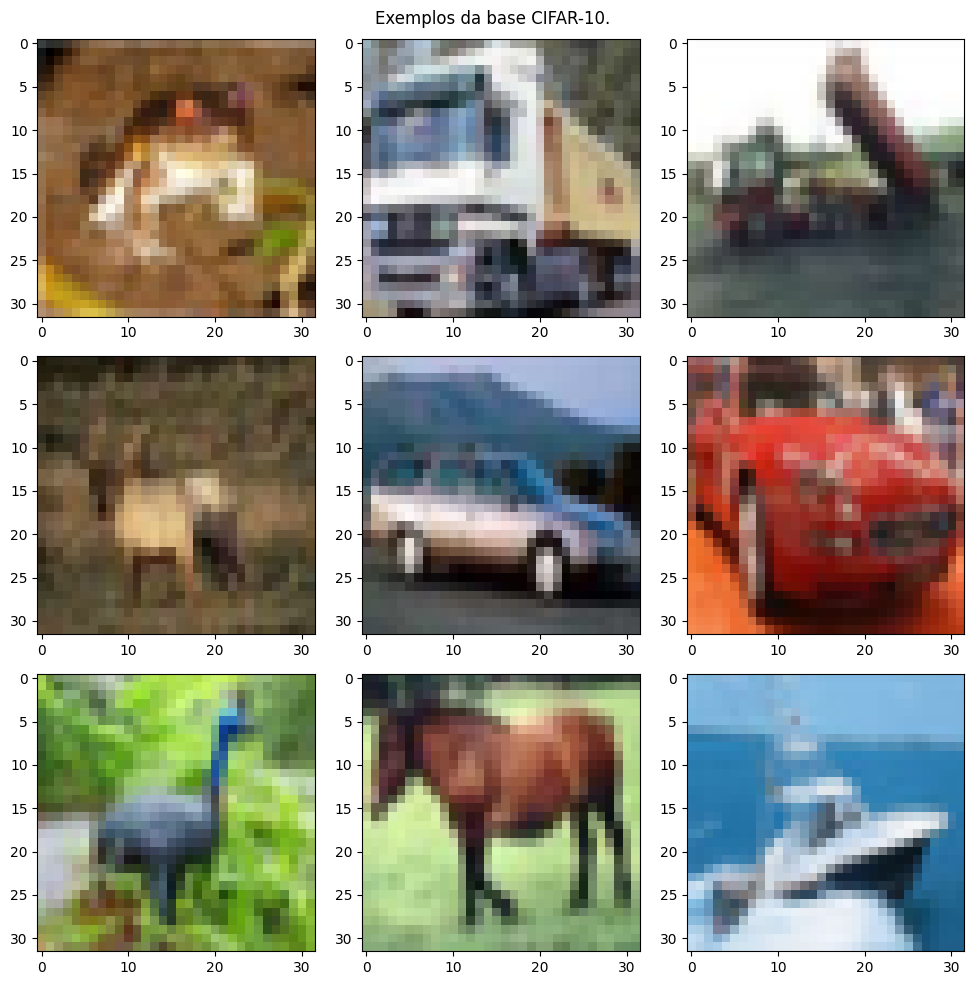

In [3]:
plt.figure(figsize=(10,10))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(X_train[i])
  plt.suptitle("Exemplos da base CIFAR-10.")
  plt.tight_layout()
  plt.show

Criação do Modelo CNN

In [8]:
model = keras.Sequential()

# Camada de entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3,3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

# Classificação
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

# Compilação
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,154 (102.16 KB)

 Trainable params: 26,154 (102.16 KB)

 Non-trainable params: 0 (0.00 B)

Treinar a rede

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs = 10,
    batch_size = 64,
    validation_split = 0.2)


Epoch 1/10
473/625 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.2572 - loss: 2.0043